
# 🩺 Diabetes Prediction — Revised Pipeline (False Positive Oriented)

Notebook ini merevisi versi sebelumnya dengan fokus utama:

- **mengurangi false positive**
- **menghilangkan leakage** pada preprocessing / threshold tuning
- **menambah model tabular yang relevan**
- **menambahkan stacking**
- **mengekspor bundle inference** yang lebih rapi

## Perubahan utama
1. **Train/test split dilakukan sebelum preprocessing**
2. Semua step preprocessing dilakukan **fit hanya di train**
3. Evaluasi model tidak hanya ROC-AUC, tapi juga:
   - Precision
   - Recall
   - Specificity
   - FPR
   - PR-AUC
4. Threshold dicari dari **out-of-fold probabilities** pada train set, **bukan dari train fit langsung**
5. Ditambahkan model:
   - Extra Trees
   - HistGradientBoosting
   - XGBoost *(jika tersedia)*
   - CatBoost *(opsional, jika tersedia)*
   - Stacking
6. Export model menyimpan:
   - fitted pipeline
   - threshold terbaik
   - required columns
   - informasi model pemenang

> **Catatan:** file dataset diasumsikan berada di `./dataset/diabetes.csv`


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from IPython.display import display
from sklearn.experimental import enable_iterative_imputer  # noqa: F401

from scipy.stats import randint, uniform, loguniform

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV
)
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('✅ Library siap')
print(f'XGBoost tersedia  : {HAS_XGB}')
print(f'CatBoost tersedia : {HAS_CATBOOST}')


✅ Library siap
XGBoost tersedia  : True
CatBoost tersedia : True



## 1. Load data


In [2]:

df = pd.read_csv('./dataset/diabetes.csv')

print(f'Shape: {df.shape}')
display(df.head())


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:

print('=== Info ===')
df.info()

print('\n=== Missing values asli ===')
display(df.isna().sum().to_frame('missing'))

print('\n=== Distribusi target ===')
target_dist = df['Outcome'].value_counts().sort_index()
display(pd.DataFrame({
    'count': target_dist,
    'pct': (target_dist / len(df) * 100).round(2)
}))


=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Missing values asli ===


,missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



=== Distribusi target ===


,count,pct
Outcome,,
0,500,65.1
1,268,34.9


,feature,zero_count,zero_pct
3,Insulin,374,48.70
2,SkinThickness,227,29.56
1,BloodPressure,35,4.56
4,BMI,11,1.43
0,Glucose,5,0.65


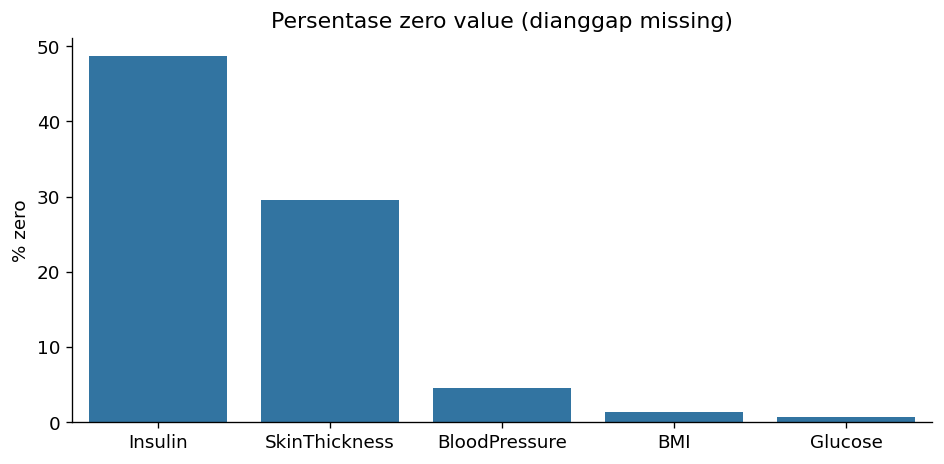

In [4]:

ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
BASE_COLS = [c for c in df.columns if c != 'Outcome']

zero_stats = []
for col in ZERO_COLS:
    n_zero = int((df[col] == 0).sum())
    zero_stats.append({
        'feature': col,
        'zero_count': n_zero,
        'zero_pct': round(n_zero / len(df) * 100, 2)
    })

zero_df = pd.DataFrame(zero_stats).sort_values('zero_pct', ascending=False)
display(zero_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=zero_df, x='feature', y='zero_pct', ax=ax)
ax.set_title('Persentase zero value (dianggap missing)')
ax.set_ylabel('% zero')
ax.set_xlabel('')
plt.tight_layout()
plt.show()



## 2. Helper, custom feature engineering, dan metric

Di versi revisi ini, feature engineering dibungkus ke transformer supaya aman dipakai di dalam CV dan tuning.

### Perubahan penting
- zero value pada kolom tertentu diubah menjadi `NaN`
- ditambahkan **missing indicator**
- winsor/clipping hanya untuk fitur yang memang cenderung sangat skewed
- feature engineering dilakukan **sebelum imputation**


In [ ]:

def make_calibrator(estimator, method='sigmoid', cv=5):
    try:
        return CalibratedClassifierCV(estimator=estimator, method=method, cv=cv)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=estimator, method=method, cv=cv)


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    denom = tn + fp
    return tn / denom if denom else 0.0


def false_positive_rate(y_true, y_pred):
    return 1.0 - specificity_score(y_true, y_pred)


def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        'threshold': float(threshold),
        'precision': float(precision),
        'recall': float(recall),
        'specificity': float(specificity),
        'fpr': float(fpr),
        'f1': float(f1),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp)
    }


def search_best_threshold(y_true, y_prob, recall_floor=0.60):
    rows = []
    thresholds = np.round(np.arange(0.05, 0.951, 0.005), 3)

    for t in thresholds:
        rows.append(evaluate_at_threshold(y_true, y_prob, t))

    thr_df = pd.DataFrame(rows)

    filtered = thr_df[thr_df['recall'] >= recall_floor].copy()

    if len(filtered) == 0:
        best_row = thr_df.sort_values(
            ['recall', 'precision', 'specificity'],
            ascending=[False, False, False]
        ).iloc[0]
    else:
        best_row = filtered.sort_values(
            ['fpr', 'precision', 'specificity', 'f1'],
            ascending=[True, False, False, False]
        ).iloc[0]

    return thr_df, best_row.to_dict()


class DiabetesFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        zero_cols=None,
        clip_cols=None,
        lower_q=0.01,
        upper_q=0.99
    ):
        self.zero_cols = zero_cols if zero_cols is not None else ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
        self.clip_cols = clip_cols if clip_cols is not None else ['Insulin', 'SkinThickness', 'DiabetesPedigreeFunction', 'BMI']
        self.lower_q = lower_q
        self.upper_q = upper_q

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.input_columns_ = X.columns.tolist()

        X_tmp = X.copy()
        for col in self.zero_cols:
            X_tmp[col] = X_tmp[col].replace(0, np.nan)

        self.clip_bounds_ = {}
        for col in self.clip_cols:
            if col in X_tmp.columns:
                series = pd.to_numeric(X_tmp[col], errors='coerce')
                low = float(series.quantile(self.lower_q))
                high = float(series.quantile(self.upper_q))
                self.clip_bounds_[col] = (low, high)

        self.feature_names_ = self._transform_internal(X).columns.tolist()
        return self

    def _transform_internal(self, X):
        X = pd.DataFrame(X).copy()

        for col in self.zero_cols:
            X[f'{col}_was_zero'] = (pd.to_numeric(X[col], errors='coerce') == 0).astype(int)

        for col in self.zero_cols:
            X[col] = pd.to_numeric(X[col], errors='coerce').replace(0, np.nan)

        for col, (low, high) in getattr(self, 'clip_bounds_', {}).items():
            if col in X.columns:
                X[col] = X[col].clip(low, high)

        X['Glucose_BMI'] = X['Glucose'] * X['BMI']
        X['Glucose_Age'] = X['Glucose'] * X['Age']
        X['Insulin_Glucose'] = X['Insulin'] / (X['Glucose'] + 1)
        X['BMI_squared'] = X['BMI'] ** 2
        X['Preg_Age'] = X['Pregnancies'] * X['Age']
        X['BMI_Age'] = X['BMI'] * X['Age']

        X['BMI_cat'] = pd.cut(
            X['BMI'],
            bins=[0, 18.5, 25, 30, np.inf],
            labels=[0, 1, 2, 3],
            include_lowest=True
        ).astype(float)

        X['Age_group'] = pd.cut(
            X['Age'],
            bins=[0, 30, 45, 60, np.inf],
            labels=[0, 1, 2, 3],
            include_lowest=True
        ).astype(float)

        return X

    def transform(self, X):
        X_t = self._transform_internal(X)
        X_t = X_t.apply(pd.to_numeric, errors='coerce')
        return X_t

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_)



## 3. Split data **sebelum** preprocessing

Ini penting untuk menghindari leakage.


In [6]:

X = df[BASE_COLS].copy()
y = df['Outcome'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'Positive rate train: {y_train.mean():.3f}')
print(f'Positive rate test : {y_test.mean():.3f}')


X_train: (614, 8)
X_test : (154, 8)
Positive rate train: 0.349
Positive rate test : 0.351



## 4. Definisikan pipeline model

Semua model dibungkus dengan pipeline berikut:

1. `DiabetesFeatureEngineer`
2. `IterativeImputer`
3. `StandardScaler`
4. model classifier

Walau model tree tidak butuh scaling, pipeline dibuat seragam agar evaluasi lebih konsisten.


In [7]:

def build_pipeline(model):
    return Pipeline(steps=[
        ('feat', DiabetesFeatureEngineer(zero_cols=ZERO_COLS)),
        ('imputer', IterativeImputer(random_state=SEED, max_iter=15, initial_strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])


models = {
    'Logistic Regression': build_pipeline(
        LogisticRegression(max_iter=3000, random_state=SEED)
    ),
    'SVM (RBF)': build_pipeline(
        SVC(C=1.0, kernel='rbf', probability=True, random_state=SEED)
    ),
    'Random Forest': build_pipeline(
        RandomForestClassifier(
            n_estimators=400,
            random_state=SEED,
            class_weight=None
        )
    ),
    'Extra Trees': build_pipeline(
        ExtraTreesClassifier(
            n_estimators=500,
            random_state=SEED,
            class_weight=None
        )
    ),
    'HistGradientBoosting': build_pipeline(
        HistGradientBoostingClassifier(random_state=SEED)
    )
}

if HAS_XGB:
    models['XGBoost'] = build_pipeline(
        xgb.XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=2.0,
            min_child_weight=3,
            gamma=0.0,
            eval_metric='logloss',
            random_state=SEED,
            verbosity=0
        )
    )

if HAS_CATBOOST:
    models['CatBoost'] = build_pipeline(
        CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            loss_function='Logloss',
            verbose=0,
            random_seed=SEED
        )
    )

print('Model yang akan dibenchmark:')
for name in models:
    print('-', name)


Model yang akan dibenchmark:
- Logistic Regression
- SVM (RBF)
- Random Forest
- Extra Trees
- HistGradientBoosting
- XGBoost
- CatBoost



## 5. Benchmark baseline dengan metrik yang lebih relevan ke false positive


In [8]:

from sklearn.metrics import make_scorer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'specificity': make_scorer(specificity_score)
}

benchmark_rows = []

for name, pipe in models.items():
    cv_res = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {
        'model': name,
        'roc_auc_mean': cv_res['test_roc_auc'].mean(),
        'pr_auc_mean': cv_res['test_pr_auc'].mean(),
        'precision_mean': cv_res['test_precision'].mean(),
        'recall_mean': cv_res['test_recall'].mean(),
        'f1_mean': cv_res['test_f1'].mean(),
        'specificity_mean': cv_res['test_specificity'].mean(),
    }
    row['fpr_mean'] = 1 - row['specificity_mean']
    benchmark_rows.append(row)

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    ['fpr_mean', 'precision_mean', 'pr_auc_mean'],
    ascending=[True, False, False]
).reset_index(drop=True)

display(benchmark_df.style.format({
    c: '{:.4f}' for c in benchmark_df.columns if c != 'model'
}))


,model,roc_auc_mean,pr_auc_mean,precision_mean,recall_mean,f1_mean,specificity_mean,fpr_mean
0,Logistic Regression,0.8406,0.7426,0.7331,0.5748,0.6419,0.8850,0.1150
1,SVM (RBF),0.8330,0.7423,0.7119,0.5654,0.6273,0.8750,0.1250
2,Extra Trees,0.8236,0.6952,0.6782,0.5654,0.6137,0.8500,0.1500
3,Random Forest,0.8272,0.7040,0.6775,0.6029,0.6356,0.8425,0.1575
4,XGBoost,0.8205,0.7031,0.6709,0.6264,0.6456,0.8325,0.1675
5,HistGradientBoosting,0.7986,0.6680,0.6198,0.5608,0.5858,0.8100,0.1900
6,CatBoost,nan,nan,nan,nan,nan,nan,nan


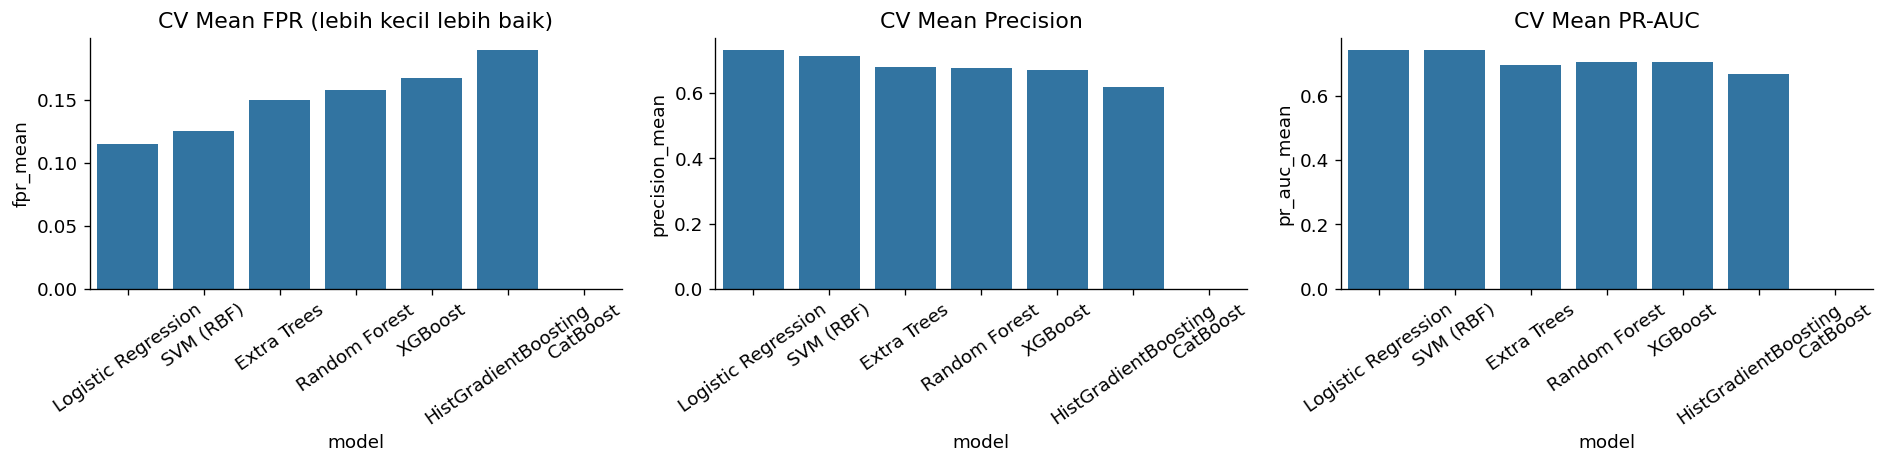

In [9]:

plot_df = benchmark_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=plot_df, x='model', y='fpr_mean', ax=axes[0])
axes[0].set_title('CV Mean FPR (lebih kecil lebih baik)')
axes[0].tick_params(axis='x', rotation=35)

sns.barplot(data=plot_df, x='model', y='precision_mean', ax=axes[1])
axes[1].set_title('CV Mean Precision')
axes[1].tick_params(axis='x', rotation=35)

sns.barplot(data=plot_df, x='model', y='pr_auc_mean', ax=axes[2])
axes[2].set_title('CV Mean PR-AUC')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()



## 6. Tuning model kandidat

Agar notebook tetap realistis untuk dataset kecil, tuning difokuskan ke model yang paling menjanjikan untuk tabular kecil-menengah:

- Logistic Regression
- Extra Trees
- HistGradientBoosting / XGBoost


In [10]:

search_spaces = {
    'Logistic Regression': {
        'model__C': loguniform(1e-3, 1e2),
        'model__penalty': ['l1', 'l2', 'elasticnet'],
        'model__solver': ['saga'],
        'model__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
        'model__class_weight': [
            None,
            'balanced',
            {0: 1.2, 1: 1.0},
            {0: 1.4, 1: 1.0}
        ]
    },
    'Extra Trees': {
        'model__n_estimators': randint(300, 900),
        'model__max_depth': [None, 4, 6, 8, 10, 14],
        'model__min_samples_split': randint(2, 12),
        'model__min_samples_leaf': randint(1, 8),
        'model__max_features': ['sqrt', 'log2', 0.5, 0.7, 1.0],
        'model__class_weight': [
            None,
            'balanced',
            {0: 1.2, 1: 1.0},
            {0: 1.4, 1: 1.0}
        ]
    },
    'HistGradientBoosting': {
        'model__learning_rate': loguniform(1e-2, 2e-1),
        'model__max_depth': [None, 3, 4, 5, 6],
        'model__max_leaf_nodes': randint(15, 50),
        'model__min_samples_leaf': randint(10, 40),
        'model__l2_regularization': loguniform(1e-4, 1e1)
    }
}

if HAS_XGB:
    search_spaces['XGBoost'] = {
        'model__n_estimators': randint(200, 700),
        'model__max_depth': randint(2, 6),
        'model__learning_rate': loguniform(1e-2, 2e-1),
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__min_child_weight': randint(1, 6),
        'model__gamma': uniform(0.0, 0.4),
        'model__reg_alpha': loguniform(1e-3, 2.0),
        'model__reg_lambda': loguniform(1e-2, 20.0),
        'model__scale_pos_weight': [0.8, 1.0, 1.2]
    }

tuned_estimators = {}
tuning_summary = []

candidate_order = ['Logistic Regression', 'Extra Trees']
candidate_order.append('XGBoost' if HAS_XGB else 'HistGradientBoosting')

for name in candidate_order:
    print(f'\n===== Tuning: {name} =====')
    rs = RandomizedSearchCV(
        estimator=models[name],
        param_distributions=search_spaces[name],
        n_iter=25,
        scoring='average_precision',
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=1
    )
    rs.fit(X_train, y_train)

    tuned_estimators[name] = rs.best_estimator_
    tuning_summary.append({
        'model': name,
        'best_pr_auc_cv': rs.best_score_,
        'best_params': rs.best_params_
    })

tuning_df = pd.DataFrame(tuning_summary).sort_values('best_pr_auc_cv', ascending=False).reset_index(drop=True)
display(tuning_df[['model', 'best_pr_auc_cv']].style.format({'best_pr_auc_cv': '{:.4f}'}))



===== Tuning: Logistic Regression =====
Fitting 5 folds for each of 25 candidates, totalling 125 fits

===== Tuning: Extra Trees =====
Fitting 5 folds for each of 25 candidates, totalling 125 fits

===== Tuning: XGBoost =====
Fitting 5 folds for each of 25 candidates, totalling 125 fits


,model,best_pr_auc_cv
0,Logistic Regression,0.7538
1,Extra Trees,0.7508
2,XGBoost,0.7398



## 7. Kalibrasi + threshold tuning berbasis out-of-fold probabilities

Tujuan tahap ini:

- probabilitas lebih stabil
- threshold tidak dipilih dari train prediction yang overfit
- pemilihan threshold diarahkan untuk **menekan false positive**


In [11]:

recall_floor = 0.60

candidate_results = {}
threshold_tables = {}

for name, est in tuned_estimators.items():
    print(f'\n===== OOF threshold search: {name} =====')

    calibrated_est = make_calibrator(est, method='sigmoid', cv=5)

    oof_prob = cross_val_predict(
        calibrated_est,
        X_train,
        y_train,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    thr_df, best_thr_row = search_best_threshold(y_train, oof_prob, recall_floor=recall_floor)

    threshold_tables[name] = thr_df
    candidate_results[name] = {
        'model': name,
        'oof_pr_auc': average_precision_score(y_train, oof_prob),
        'oof_roc_auc': roc_auc_score(y_train, oof_prob),
        'selected_threshold': best_thr_row['threshold'],
        'oof_precision': best_thr_row['precision'],
        'oof_recall': best_thr_row['recall'],
        'oof_specificity': best_thr_row['specificity'],
        'oof_fpr': best_thr_row['fpr'],
        'oof_f1': best_thr_row['f1']
    }

candidate_df = pd.DataFrame(candidate_results.values()).sort_values(
    ['oof_fpr', 'oof_precision', 'oof_pr_auc'],
    ascending=[True, False, False]
).reset_index(drop=True)

display(candidate_df.style.format({
    c: '{:.4f}' for c in candidate_df.columns if c != 'model'
}))



===== OOF threshold search: Logistic Regression =====

===== OOF threshold search: Extra Trees =====

===== OOF threshold search: XGBoost =====


,model,oof_pr_auc,oof_roc_auc,selected_threshold,oof_precision,oof_recall,oof_specificity,oof_fpr,oof_f1
0,Logistic Regression,0.7292,0.8425,0.4600,0.7247,0.6028,0.8775,0.1225,0.6582
1,Extra Trees,0.7213,0.8450,0.4700,0.7238,0.6121,0.8750,0.1250,0.6633
2,XGBoost,0.7103,0.8422,0.4500,0.6979,0.6262,0.8550,0.1450,0.6601


Model kandidat terbaik (berdasarkan OOF FP-oriented selection): Logistic Regression
Threshold terpilih: 0.460


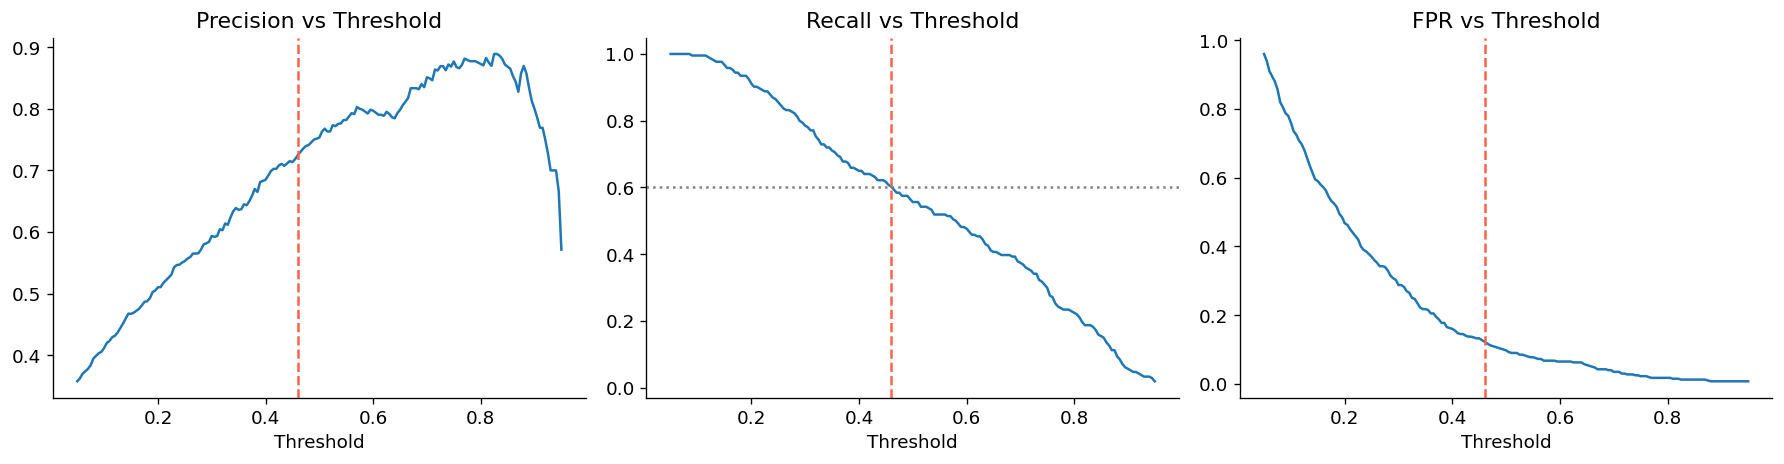

In [12]:

best_candidate_name = candidate_df.iloc[0]['model']
best_candidate_threshold = float(candidate_df.iloc[0]['selected_threshold'])

print(f'Model kandidat terbaik (berdasarkan OOF FP-oriented selection): {best_candidate_name}')
print(f'Threshold terpilih: {best_candidate_threshold:.3f}')

thr_plot_df = threshold_tables[best_candidate_name]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(thr_plot_df['threshold'], thr_plot_df['precision'])
axes[0].axvline(best_candidate_threshold, color='tomato', ls='--')
axes[0].set_title('Precision vs Threshold')

axes[1].plot(thr_plot_df['threshold'], thr_plot_df['recall'])
axes[1].axvline(best_candidate_threshold, color='tomato', ls='--')
axes[1].axhline(recall_floor, color='gray', ls=':')
axes[1].set_title('Recall vs Threshold')

axes[2].plot(thr_plot_df['threshold'], thr_plot_df['fpr'])
axes[2].axvline(best_candidate_threshold, color='tomato', ls='--')
axes[2].set_title('FPR vs Threshold')

for ax in axes:
    ax.set_xlabel('Threshold')

plt.tight_layout()
plt.show()



## 8. Tambahkan stacking

Stacking dibangun dari estimator yang sudah dituning, lalu:
- dikalibrasi
- dicari threshold terbaik dengan prosedur yang sama


In [13]:

stack_estimators = []
for name in tuned_estimators:
    alias = ''.join([w[0].lower() for w in name.replace('(', '').replace(')', '').split()])
    stack_estimators.append((alias, tuned_estimators[name]))

stack_base_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=3000, random_state=SEED),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1,
    passthrough=False
)

stack_calibrated = make_calibrator(stack_base_model, method='sigmoid', cv=5)

stack_oof_prob = cross_val_predict(
    stack_calibrated,
    X_train,
    y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

stack_thr_df, stack_best_thr = search_best_threshold(y_train, stack_oof_prob, recall_floor=recall_floor)

stack_result = {
    'model': 'Stacking',
    'oof_pr_auc': average_precision_score(y_train, stack_oof_prob),
    'oof_roc_auc': roc_auc_score(y_train, stack_oof_prob),
    'selected_threshold': stack_best_thr['threshold'],
    'oof_precision': stack_best_thr['precision'],
    'oof_recall': stack_best_thr['recall'],
    'oof_specificity': stack_best_thr['specificity'],
    'oof_fpr': stack_best_thr['fpr'],
    'oof_f1': stack_best_thr['f1']
}

comparison_with_stack = pd.concat([
    candidate_df,
    pd.DataFrame([stack_result])
], ignore_index=True).sort_values(
    ['oof_fpr', 'oof_precision', 'oof_pr_auc'],
    ascending=[True, False, False]
).reset_index(drop=True)

display(comparison_with_stack.style.format({
    c: '{:.4f}' for c in comparison_with_stack.columns if c != 'model'
}))


,model,oof_pr_auc,oof_roc_auc,selected_threshold,oof_precision,oof_recall,oof_specificity,oof_fpr,oof_f1
0,Logistic Regression,0.7292,0.8425,0.4600,0.7247,0.6028,0.8775,0.1225,0.6582
1,Extra Trees,0.7213,0.8450,0.4700,0.7238,0.6121,0.8750,0.1250,0.6633
2,Stacking,0.7251,0.8473,0.4600,0.7207,0.6028,0.8750,0.1250,0.6565
3,XGBoost,0.7103,0.8422,0.4500,0.6979,0.6262,0.8550,0.1450,0.6601


In [14]:

final_model_name = comparison_with_stack.iloc[0]['model']
final_threshold = float(comparison_with_stack.iloc[0]['selected_threshold'])

print(f'Final selected model (train OOF only): {final_model_name}')
print(f'Final threshold: {final_threshold:.3f}')

if final_model_name == 'Stacking':
    final_estimator = stack_calibrated
else:
    final_estimator = make_calibrator(tuned_estimators[final_model_name], method='sigmoid', cv=5)


Final selected model (train OOF only): Logistic Regression
Final threshold: 0.460



## 9. Fit final model di train lalu evaluasi di test


In [15]:

final_estimator.fit(X_train, y_train)

y_prob_test = final_estimator.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= final_threshold).astype(int)

test_metrics = evaluate_at_threshold(y_test, y_prob_test, final_threshold)
test_metrics['roc_auc'] = float(roc_auc_score(y_test, y_prob_test))
test_metrics['pr_auc'] = float(average_precision_score(y_test, y_prob_test))

pd.DataFrame([test_metrics]).style.format({
    c: '{:.4f}' for c in ['threshold', 'precision', 'recall', 'specificity', 'fpr', 'f1', 'roc_auc', 'pr_auc']
})


,threshold,precision,recall,specificity,fpr,f1,tn,fp,fn,tp,roc_auc,pr_auc
0,0.4600,0.6000,0.5556,0.8000,0.2000,0.5769,80,20,24,30,0.8150,0.6684


In [16]:

print('=' * 60)
print(f'FINAL MODEL: {final_model_name}')
print(f'THRESHOLD : {final_threshold:.3f}')
print('=' * 60)
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Tidak Diabetes', 'Diabetes'],
    zero_division=0
))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_test):.4f}")
print(f"FPR     : {false_positive_rate(y_test, y_pred_test):.4f}")
print(f"Specificity: {specificity_score(y_test, y_pred_test):.4f}")


FINAL MODEL: Logistic Regression
THRESHOLD : 0.460
                precision    recall  f1-score   support

Tidak Diabetes       0.77      0.80      0.78       100
      Diabetes       0.60      0.56      0.58        54

      accuracy                           0.71       154
     macro avg       0.68      0.68      0.68       154
  weighted avg       0.71      0.71      0.71       154

ROC-AUC : 0.8150
PR-AUC  : 0.6684
FPR     : 0.2000
Specificity: 0.8000


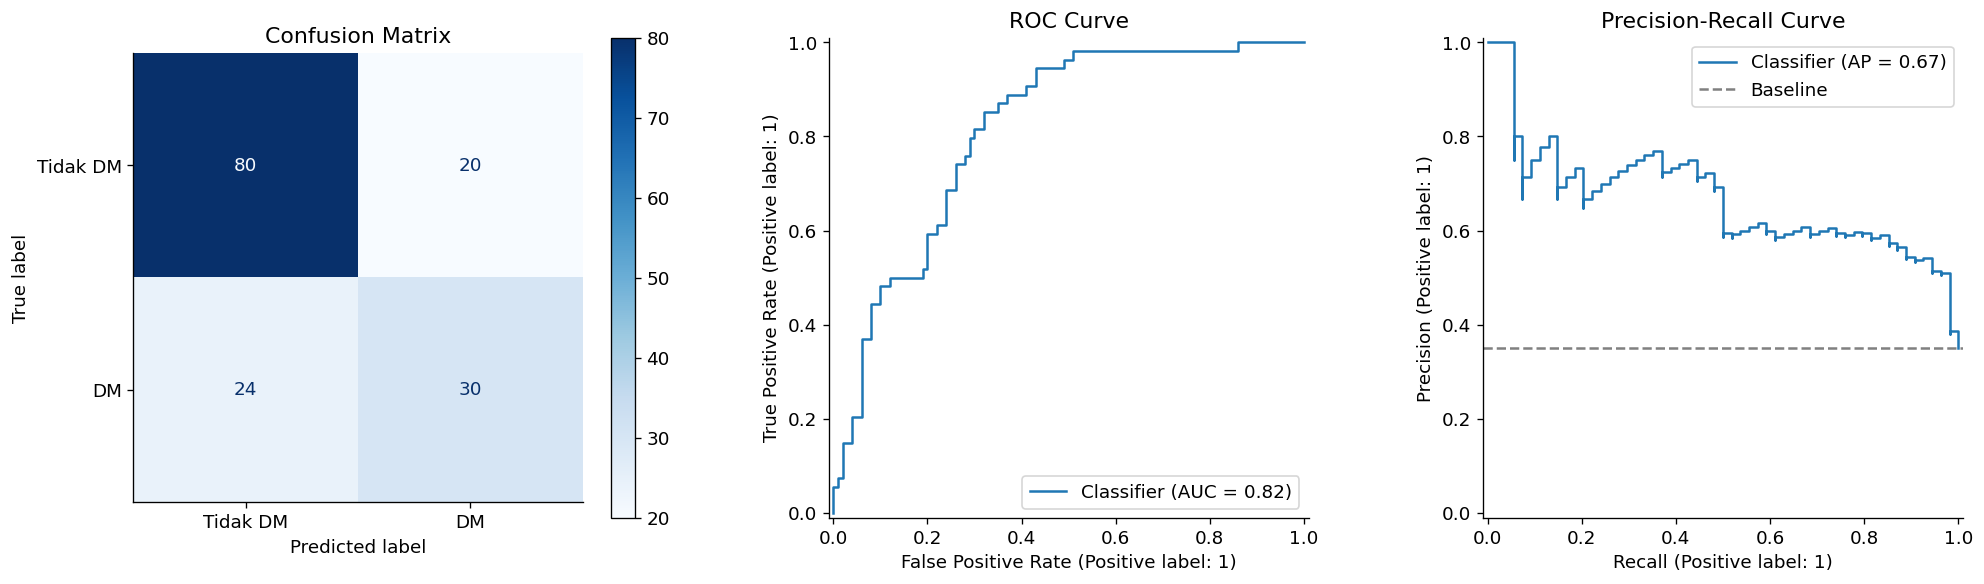

In [17]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=['Tidak DM', 'DM'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=axes[1])
axes[1].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=axes[2])
axes[2].axhline(y_test.mean(), ls='--', color='gray', label='Baseline')
axes[2].legend()
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


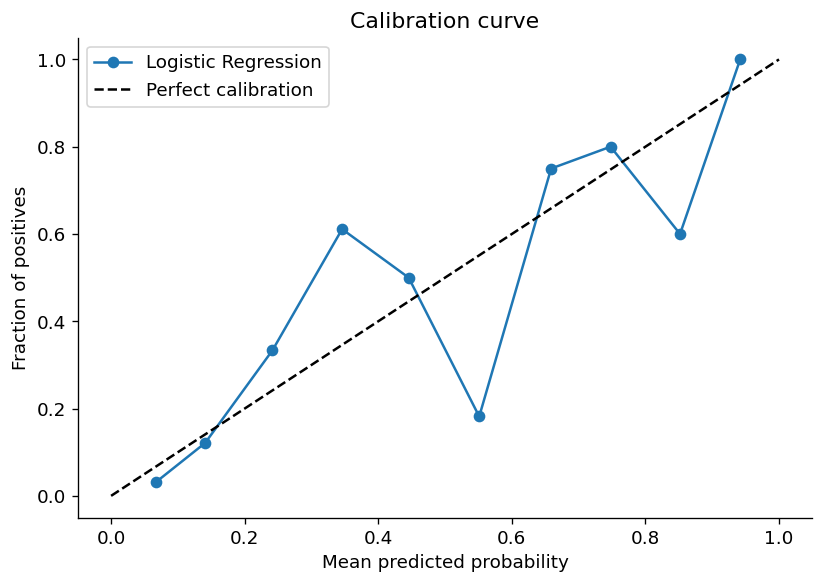

In [18]:

frac_pos, mean_pred = calibration_curve(y_test, y_prob_test, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_pred, frac_pos, 'o-', label=final_model_name)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()



## 10. Compare test performance of all tuned candidates + stacking

Bagian ini tidak dipakai untuk memilih model utama, tetapi berguna untuk melihat apakah stacking benar-benar membantu.


In [19]:

all_final_candidates = {}

for name, est in tuned_estimators.items():
    cal_est = make_calibrator(est, method='sigmoid', cv=5)
    chosen_thr = float(candidate_df.loc[candidate_df['model'] == name, 'selected_threshold'].iloc[0])

    cal_est.fit(X_train, y_train)
    prob = cal_est.predict_proba(X_test)[:, 1]
    metrics_row = evaluate_at_threshold(y_test, prob, chosen_thr)
    metrics_row['roc_auc'] = float(roc_auc_score(y_test, prob))
    metrics_row['pr_auc'] = float(average_precision_score(y_test, prob))
    metrics_row['model'] = name
    all_final_candidates[name] = metrics_row

stack_final = clone(stack_calibrated)
stack_final.fit(X_train, y_train)
stack_prob = stack_final.predict_proba(X_test)[:, 1]
stack_metrics = evaluate_at_threshold(y_test, stack_prob, float(stack_result['selected_threshold']))
stack_metrics['roc_auc'] = float(roc_auc_score(y_test, stack_prob))
stack_metrics['pr_auc'] = float(average_precision_score(y_test, stack_prob))
stack_metrics['model'] = 'Stacking'
all_final_candidates['Stacking'] = stack_metrics

all_test_df = pd.DataFrame(all_final_candidates.values()).sort_values(
    ['fpr', 'precision', 'pr_auc'],
    ascending=[True, False, False]
).reset_index(drop=True)

display(all_test_df.style.format({
    c: '{:.4f}' for c in all_test_df.columns if c not in ['model', 'tn', 'fp', 'fn', 'tp']
}))


,threshold,precision,recall,specificity,fpr,f1,tn,fp,fn,tp,roc_auc,pr_auc,model
0,0.4700,0.6346,0.6111,0.8100,0.1900,0.6226,81,19,21,33,0.8237,0.6917,Extra Trees
1,0.4600,0.6000,0.5556,0.8000,0.2000,0.5769,80,20,24,30,0.8150,0.6684,Logistic Regression
2,0.4600,0.5918,0.5370,0.8000,0.2000,0.5631,80,20,25,29,0.8213,0.6812,Stacking
3,0.4500,0.6182,0.6296,0.7900,0.2100,0.6239,79,21,20,34,0.8169,0.6907,XGBoost



## 11. Interpretasi sederhana dengan permutation importance

Karena pipeline sekarang lebih kompleks dan leakage-safe, interpretasi yang paling stabil untuk notebook ini adalah **permutation importance**.


,feature,importance_mean,importance_std
1,Glucose,0.180034,0.039639
5,BMI,0.045877,0.031289
0,Pregnancies,0.020304,0.015015
6,DiabetesPedigreeFunction,0.008030,0.005680
7,Age,0.005364,0.010429
2,BloodPressure,0.003414,0.005373
4,Insulin,0.000608,0.001696
3,SkinThickness,-0.000080,0.000090


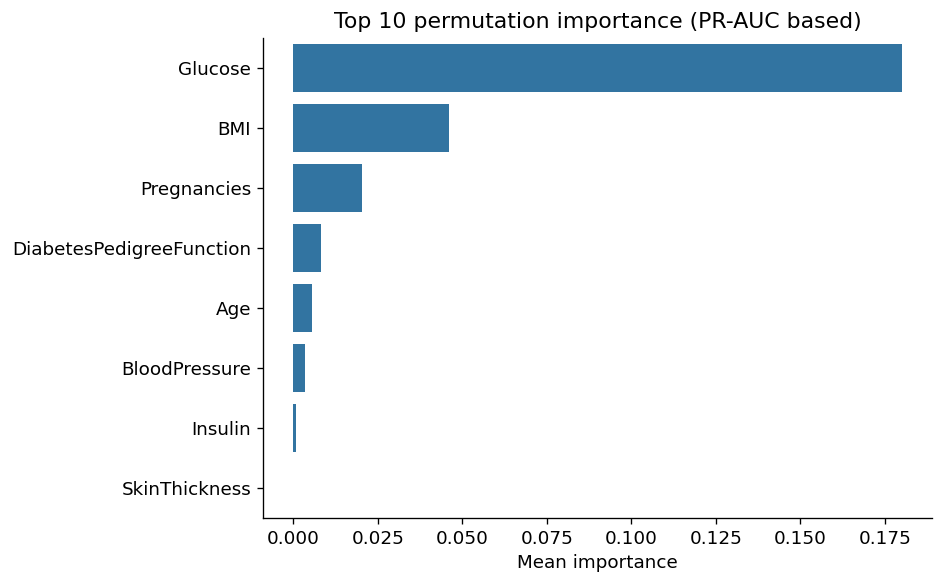

In [20]:

perm = permutation_importance(
    final_estimator,
    X_test,
    y_test,
    n_repeats=20,
    random_state=SEED,
    scoring='average_precision',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_df.head(10))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=perm_df.head(10), x='importance_mean', y='feature', ax=ax)
ax.set_title('Top 10 permutation importance (PR-AUC based)')
ax.set_xlabel('Mean importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()



## 12. Contoh prediksi individual


In [21]:

sample_idx = X_test.index[0]
sample_df = X_test.loc[[sample_idx]].copy()

sample_prob = final_estimator.predict_proba(sample_df)[:, 1][0]
sample_pred = int(sample_prob >= final_threshold)
actual = int(y_test.loc[sample_idx])

print(f'Index data      : {sample_idx}')
print(f'Probabilitas DM : {sample_prob:.4f}')
print(f'Prediksi        : {sample_pred}')
print(f'Aktual          : {actual}')


Index data      : 44
Probabilitas DM : 0.5419
Prediksi        : 1
Aktual          : 0



## 13. Export bundle untuk inference


In [22]:

bundle = {
    'model': final_estimator,
    'threshold': float(final_threshold),
    'model_name': final_model_name,
    'required_cols': BASE_COLS,
    'zero_cols': ZERO_COLS,
    'selection_strategy': 'OOF threshold search with recall floor',
    'recall_floor': recall_floor,
    'test_metrics': test_metrics
}

joblib.dump(bundle, 'diabetes_revised_bundle.pkl')
print('✅ Bundle disimpan ke diabetes_revised_bundle.pkl')


✅ Bundle disimpan ke diabetes_revised_bundle.pkl


In [23]:

def predict_from_bundle(bundle_path, raw_df):
    bundle = joblib.load(bundle_path)

    required_cols = bundle['required_cols']
    threshold = bundle['threshold']
    model = bundle['model']

    missing_cols = [c for c in required_cols if c not in raw_df.columns]
    if missing_cols:
        raise ValueError(f'Kolom tidak ditemukan: {missing_cols}')

    X_new = raw_df[required_cols].copy()
    probs = model.predict_proba(X_new)[:, 1]
    preds = (probs >= threshold).astype(int)

    out = raw_df.copy()
    out['diabetes_probability'] = probs
    out['predicted_label'] = preds
    out['risk_score_0_100'] = np.round(probs * 100, 2)
    return out

print('✅ Helper inference siap dipakai')


✅ Helper inference siap dipakai



## 14. Ringkasan improvement yang sudah masuk ke notebook ini

- leakage pada preprocessing dihilangkan
- threshold tuning dipindah ke **OOF probability**
- metrik evaluasi diperluas untuk fokus ke **false positive**
- missing indicator ditambahkan
- model tabular yang lebih kuat ditambahkan
- stacking ditambahkan
- export bundle dibuat lebih aman dan simpel

### Catatan praktis
Kalau targetmu adalah **menekan false positive lebih jauh lagi**, biasanya tuas yang paling efektif adalah:

1. naikkan `recall_floor` bila kamu masih ingin menjaga sensitivitas minimum tertentu
2. atau naikkan threshold final sedikit di atas hasil otomatis
3. atau prioritaskan model dengan `fpr` paling rendah meski recall turun sedikit
